# **MNIST CLASSIFICATION WITH DEEP LEARNING(CNN)**

> ## Intro to data set & Notebook Overview

The MNIST (Modified National Institute of Standards and Technology) dataset is one of the most popular datasets in Machine Learning and Deep Learning for image classification tasks.


Dataset Information
Total Images: 70,000 handwritten digit images
Training Images: 60,000
Testing Images: 10,000
Classes: 10 (digits 0–9)
Image Size: 28 × 28 pixels
Color Format: Grayscale (Black & White)
Pixel Range: 0–255

This Notebook contains normalizing the data and model building and predicting and evaluation of the model

> ## Load the Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization

> ## Important Terms 

`**Input Layers**`: In `CNN` Input layer recieves the raw image data and passes it to the network . It takes images and give values in `3D` Vol(H*W*B).

` **COnvolutional Layer**`  : It is a core block of CNN . It is used to extract features from the input image.

`**Pooling Layer**` : It is used to reduce the size of the image.

`**Flatten Layer**` : It is used to convert the 2D image to 1D image.

`** Dense Layer**` : It is a fully connected layer.

`**Output Layer**` : It is used to get the final output of the model.The output layer convert final scores into probablities using ` Activation function`.

`**Sigmoid**` : It is a Activation Function converts probablities into binary classification adn `softmax function` converts probablities into multi-class classification.

verbose=0 → When you want a clean output.

verbose=1 → To monitor training progress in detail.

verbose=2 → To see results per epoch without a long progress bar.

Verbose is a parameter that controls the amount of information printed during model training or prediction.

> ## Load the MNIST dataset

In [2]:
# Load data mnist hand written digits
from tensorflow.keras.datasets import mnist
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

> ## Data Exploration

In [3]:
# check the shape of the data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


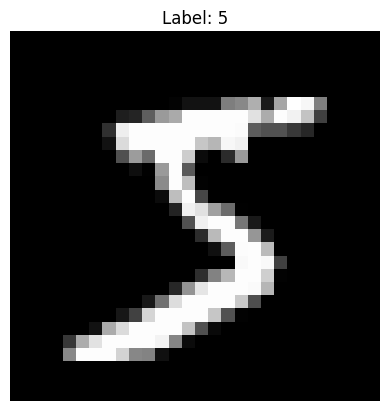

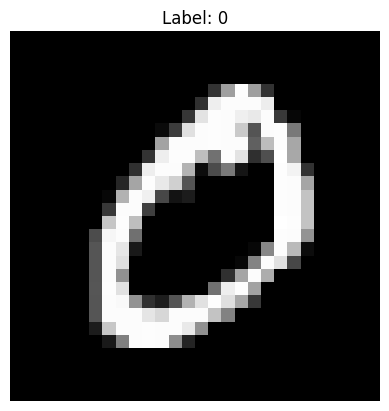

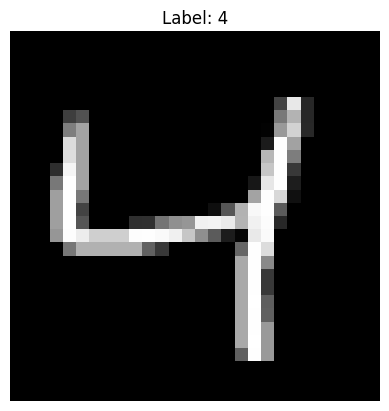

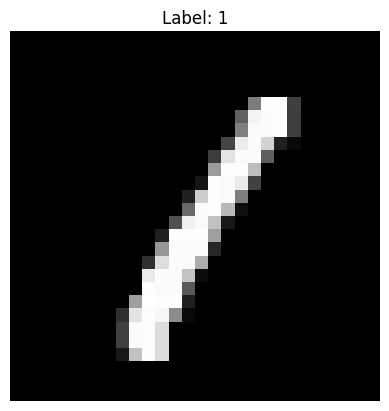

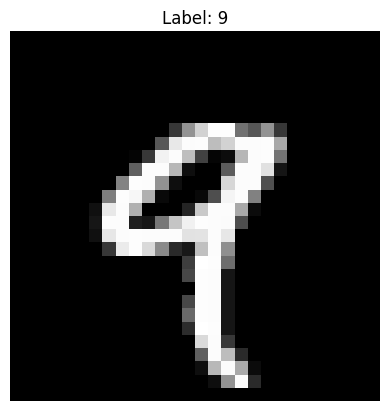

In [4]:
# See First 5 images
for i in range(5):
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
    plt.show()

In [5]:
# Show raw pixel values of the first image (not normalized)
print("Label:", y_train[0])
print("Pixel values:")
print(X_train[0])

Label: 5
Pixel values:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253

> ##  Normalizing the Data 

In [6]:
X_train=X_train/255.0
X_test=X_test/255.0

In [7]:
print("Label:", y_train[0])
print("Pixel values:")
print(X_train[0])

Label: 5
Pixel values:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        

> ## Build the model

In [8]:
model=Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax'
                          
                          )
])

model.summary()

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

> ## Compile the model

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10)

# evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)
# make predictions
predictions = model.predict(X_test)
# print the first prediction
print("First prediction:", predictions[0])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9892 - loss: 0.0354
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9931 - loss: 0.0241
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9939 - loss: 0.0204
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9953 - loss: 0.0167
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9956 - loss: 0.0137
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9963 - loss: 0.0118
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0112
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9972 - loss: 0.0093
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9978 - loss: 0.0082
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9981 - loss: 0.0069
313/313 - 1s - 3ms/step - accuracy: 0.9802 - loss: 0.0880

Test accuracy: 0.9801999926567078
313/313 ━━━━━━━━━━━━━━━

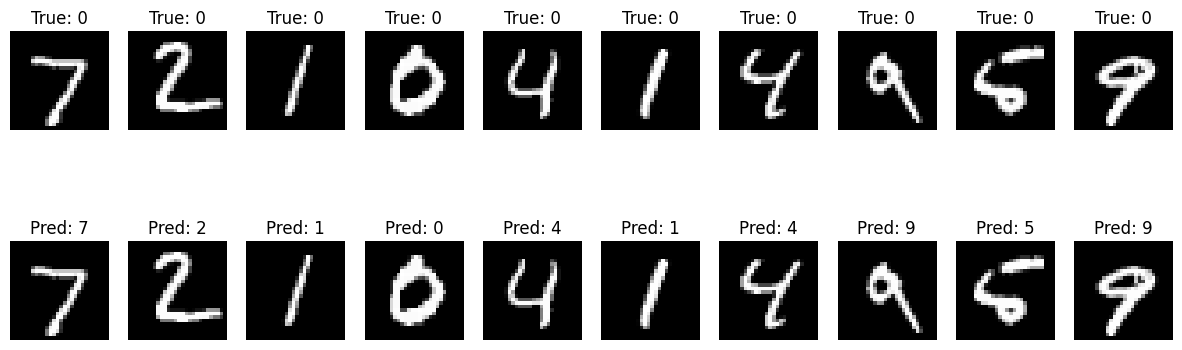

In [11]:

# Step 2: Convert predictions from probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)  # Max probability index is the predicted label

# Step 3: Visualize the first 10 test images with original vs predicted labels
plt.figure(figsize=(15, 5))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')  # Show original image
    plt.title(f"True: {np.argmax(y_test[i])}")
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')  # Show image again for predicted label
    plt.title(f"Pred: {predicted_labels[i]}")  # Predicted label
    plt.axis('off')

plt.show()